<a href="https://colab.research.google.com/github/Muhammad-AHMAD07/ML_Lab/blob/main/Lab_07(OEL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

DataSet Loading

In [3]:
data=pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')
shape=data.shape
print(shape)
data.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Data Exploration

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

/tmp/ipykernel_1208/2731681732.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=data, palette='Set2')
/tmp/ipykernel_1208/2731681732.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=data, palette='coolwarm')
/tmp/ipykernel_1208/2731681732.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Attrition', y='WorkLifeBalance', data=data, palette='muted')


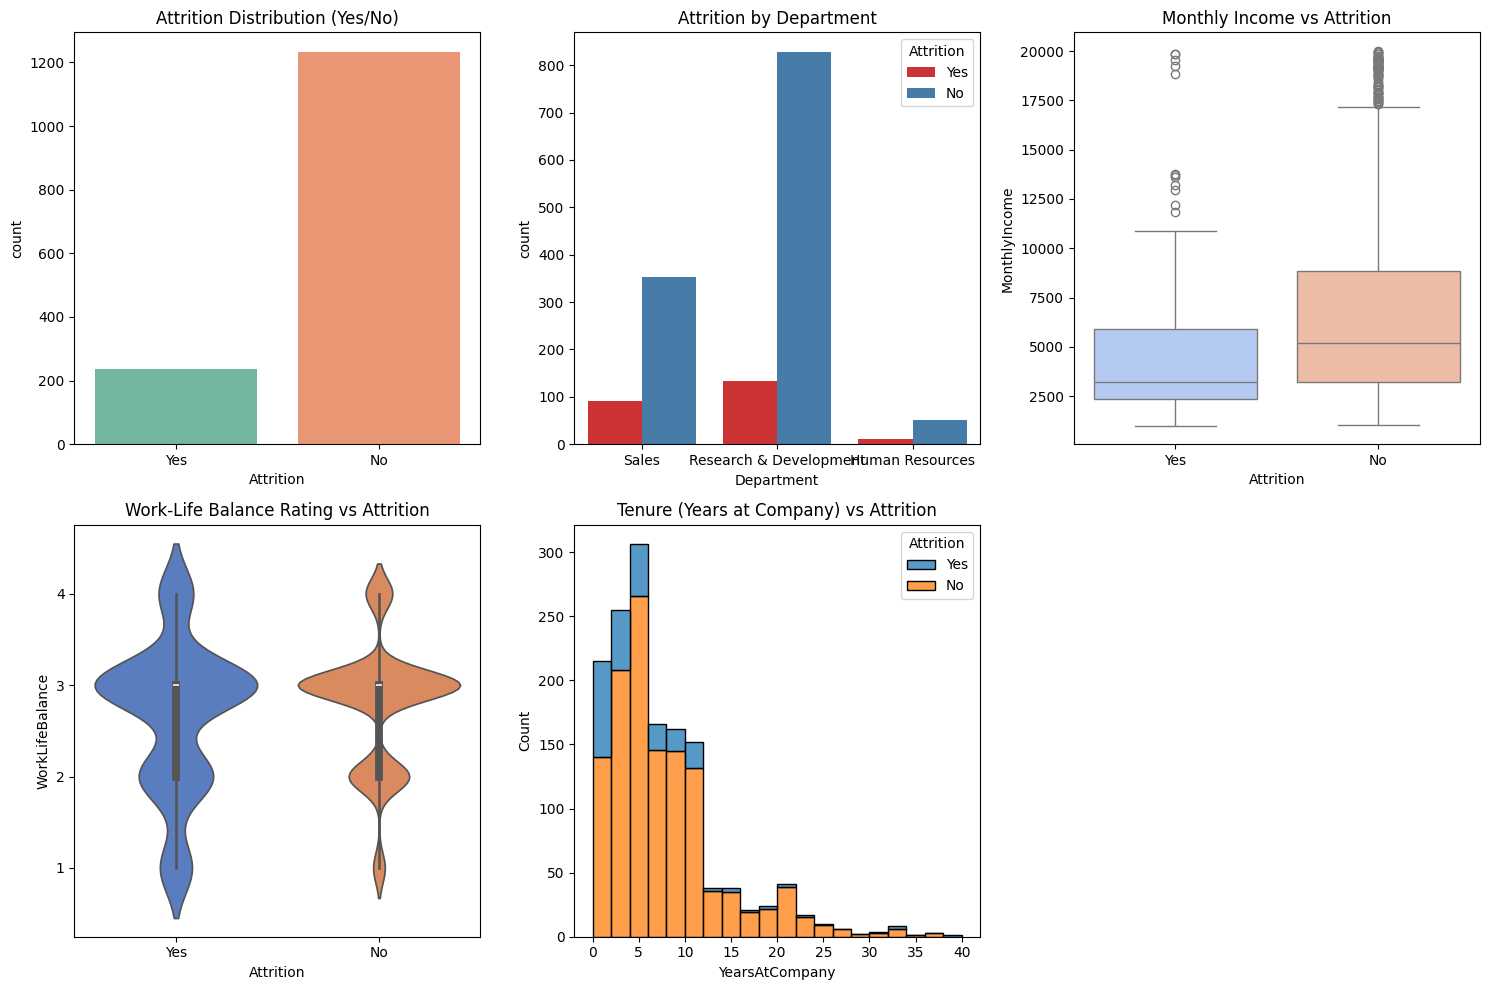

In [4]:
print(data.info())
print(data['Attrition'].value_counts())


plt.figure(figsize=(15, 10))

# 1 (Bar Plot)
plt.subplot(2, 3, 1)
sns.countplot(x='Attrition', data=data, palette='Set2')
plt.title('Attrition Distribution (Yes/No)')

# 2 (Grouped Bar Chart)
plt.subplot(2, 3, 2)
sns.countplot(x='Department', hue='Attrition', data=data, palette='Set1')
plt.title('Attrition by Department')

# 3 (Box Plot)
plt.subplot(2, 3, 3)
sns.boxplot(x='Attrition', y='MonthlyIncome', data=data, palette='coolwarm')
plt.title('Monthly Income vs Attrition')

# 4 (Violin Plot)
plt.subplot(2, 3, 4)
sns.violinplot(x='Attrition', y='WorkLifeBalance', data=data, palette='muted')
plt.title('Work-Life Balance Rating vs Attrition')

# 5 (Histogram)
plt.subplot(2, 3, 5)
sns.histplot(data=data, x='YearsAtCompany', hue='Attrition', multiple='stack', bins=20)
plt.title('Tenure (Years at Company) vs Attrition')



plt.tight_layout()
plt.show()

Data Preprocessing

In [6]:
data['Attrition'] = LabelEncoder().fit_transform(data['Attrition'])

# 4.2 Drop Irrelevant Columns
drop_cols = ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18']
data_clean = data.drop(columns=drop_cols, errors='ignore')

# 4.3 Separate Features and Target
X = data_clean.drop('Attrition', axis=1)
y = data_clean['Attrition']

# 4.4 One-Hot Encoding for Categorical Variables
X = pd.get_dummies(X, drop_first=True)

# 4.5 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



Model Selection

Model Training and Selection

In [7]:
# Model 1: Logistic Regression (with L2 Regularization)
lr_model = LogisticRegression(penalty='l2', solver='liblinear', C=1.0, max_iter=1000)
lr_model.fit(X_train, y_train)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print("Both models trained successfully.")

Both models trained successfully.


Results


Logistic Regression:
Accuracy: 0.8776 | Precision: 0.9231 | Recall: 0.2553 | F1: 0.4000 | AUC: 0.8011

Random Forest:
Accuracy: 0.8367 | Precision: 0.4444 | Recall: 0.0851 | F1: 0.1429 | AUC: 0.7515


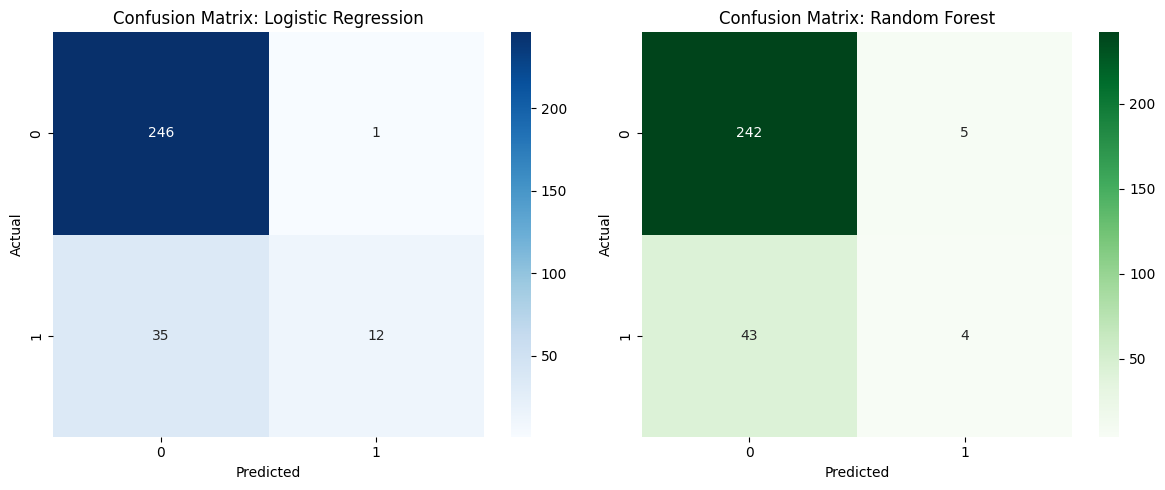

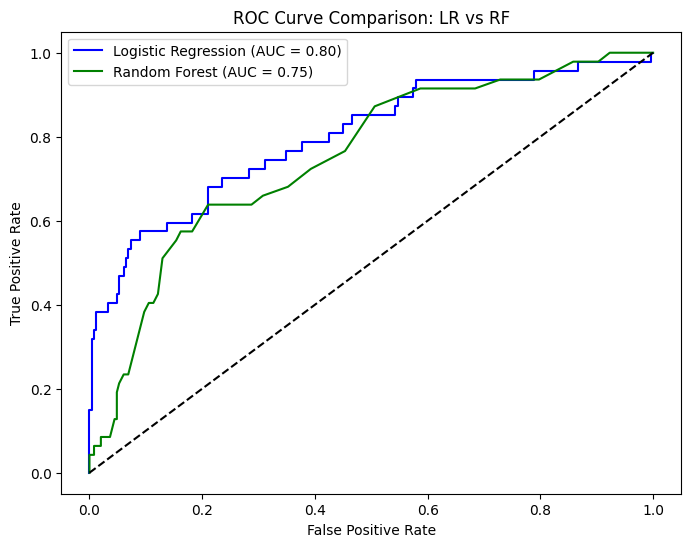

In [8]:
def get_metrics(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n{name}:")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    return y_pred, y_prob, auc


lr_pred, lr_prob, lr_auc = get_metrics(lr_model, X_test, y_test, "Logistic Regression")
rf_pred, rf_prob, rf_auc = get_metrics(rf_model, X_test, y_test, "Random Forest")

# Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix: Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.2f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: LR vs RF')
plt.legend()
plt.show()

Feature Extraction

/tmp/ipykernel_1208/978946394.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')


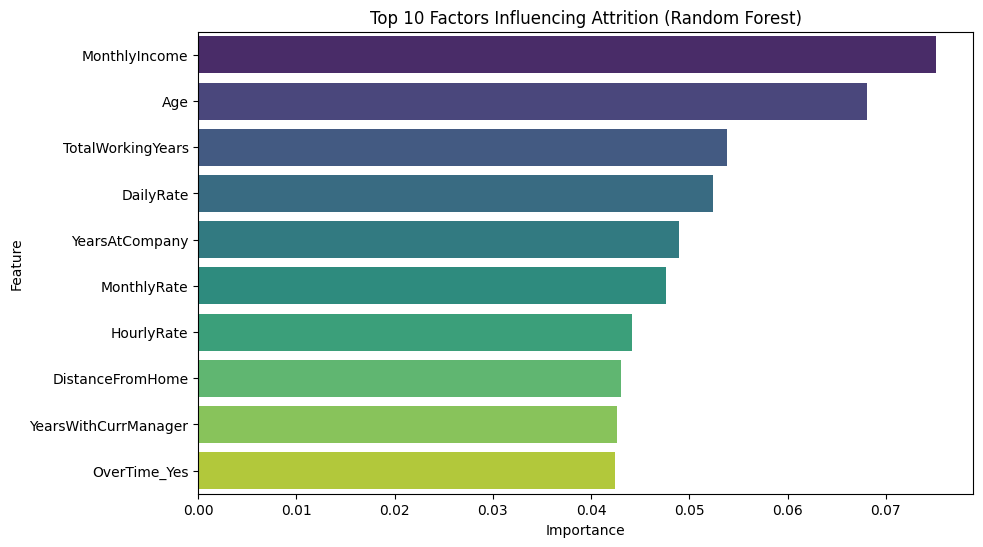

Top 5 Factors:
              Feature  Importance
9       MonthlyIncome    0.075157
0                 Age    0.068066
16  TotalWorkingYears    0.053865
1           DailyRate    0.052450
19     YearsAtCompany    0.048968

Top 5 Logistic Regression Coefficients:
                             Feature  Coefficient
43                      OverTime_Yes     1.172512
23  BusinessTravel_Travel_Frequently     0.572264
34     JobRole_Laboratory Technician     0.510493
42              MaritalStatus_Single     0.444537
13                 PerformanceRating     0.434210


In [9]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Top 10 Factors Influencing Attrition (Random Forest)')
plt.show()

print("Top 5 Factors:")
print(feat_imp.head(5))


lr_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False).head(10)

print("\nTop 5 Logistic Regression Coefficients:")
print(lr_coef.head(5))